## Arkansas EI Analysis Using PyEI

In [1]:
import pandas as pd
import numpy as np
import json
import dill
from pyei.two_by_two import TwoByTwoEI
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

import os
os.environ["PYTENSOR_FLAGS"] = "cxx=,mode=FAST_COMPILE,linker=py"

import shutil
shutil.rmtree(os.path.expanduser("~\\AppData\\Local\\PyTensor"), ignore_errors=True)

c:\Users\leeh1\Rockies-Gerrymandering\repo\rockies\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
c:\Users\leeh1\Rockies-Gerrymandering\repo\rockies\Lib\site-packages\numba\core\decorators.py:248: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [70]:
demographics = ['white', 'black', 'latino', 'other']
candidates = ['harris', 'trump']

### Path and DataFrame

In [6]:
path = '../output/Arkansas/seawulf.csv'

In [7]:
ar_df = pd.read_csv(path)
ar_df

,Unique_ID,COUNTYFP,Kamala D. Harris,Donald J. Trump,Other_candidates,Total_votes,White_population,Black_population,Latino_population,Other_population,Total_population
0,05001-81 - Stuttgart 2,1,293,639,19,951,486.169395,356.604974,32.728840,0.738939,876.242147
1,05001-36 - Gillett Ward 3,1,25,39,2,66,63.524419,10.565301,0.982819,2.213607,77.286145
2,05001-53 - Dewitt 2,1,49,188,5,242,230.348940,133.055168,0.119868,4.781286,368.305262
3,05001-51 - DeWitt 1,1,101,61,5,167,332.713262,201.772191,0.000000,7.098115,541.583568
4,05001-55 - Dewitt 3,1,42,272,3,317,36.167855,9.010094,0.713321,0.281977,46.173247
...,...,...,...,...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,149,59,93,5,157,242.266509,33.762641,53.156670,23.501428,352.687248
2677,05149-18 - Magazine 1,149,79,354,7,440,763.775521,0.000000,69.265079,45.229741,878.270341
2678,05149-29 - Ions Creek,149,0,19,0,19,141.627233,2.686700,2.303132,13.816984,160.434048
2679,05149-24 - Waveland,149,18,69,1,88,253.978789,7.573110,4.458375,9.804388,275.814662


### Isolate Columns Needed + Create Columns Necessary

[Source](https://github.com/mggg/ecological-inference/blob/main/pyei/intro_notebooks/PyEI_overview.ipynb?short_path=f3688a3)

Whether you are using an example data set or your own data, here is what you will need to pass to the various EI methods:

A vector of length `num_precincts` giving the population of each precincts. Depending on your purposes and data, the appropriate measure of population may be CVAP, VAP, etc. Below we name this `precinct_pops`.

For 2 x 2 EI:

- A vector of length `num_precincts` whose entries are each numbers between zero and 1 that give the fraction of the population of each precinct who belong to the demographic group of interest. Below we name this `group_fraction`.
- A vector of length `num_precincts` whose entries are each numbers beteween zero and 1 that give the fraction of voters in each precinct voting for the candidate of interest (or, if we are estimating turnout, who voted at all). Below, we name this `votes_fraction`.
Optionally: name of the candidate of interest, name of the demographic group of interest, and/or names of precincts (for use in PyEI's plotting and reporting).

In [ ]:
ar_df.columns = ar_df.columns.str.lower()

ar_data = ar_df[['unique_id', 'kamala d. harris', 'donald j. trump', 'total_votes', 
                 'white_population', 'black_population', 'latino_population', 'other_population', 'total_population']]
ar_data = ar_data.rename(columns={'unique_id' : 'precincts', 'kamala d. harris' : 'harris', 'donald j. trump' : 'trump'})
ar_data['total'] = ar_data['harris'] + ar_data['trump']
ar_data

,precincts,harris,trump,total_votes,white_population,black_population,latino_population,other_population,total_population,total
0,05001-81 - Stuttgart 2,293,639,951,486.169395,356.604974,32.728840,0.738939,876.242147,932
1,05001-36 - Gillett Ward 3,25,39,66,63.524419,10.565301,0.982819,2.213607,77.286145,64
2,05001-53 - Dewitt 2,49,188,242,230.348940,133.055168,0.119868,4.781286,368.305262,237
3,05001-51 - DeWitt 1,101,61,167,332.713262,201.772191,0.000000,7.098115,541.583568,162
4,05001-55 - Dewitt 3,42,272,317,36.167855,9.010094,0.713321,0.281977,46.173247,314
...,...,...,...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,59,93,157,242.266509,33.762641,53.156670,23.501428,352.687248,152
2677,05149-18 - Magazine 1,79,354,440,763.775521,0.000000,69.265079,45.229741,878.270341,433
2678,05149-29 - Ions Creek,0,19,19,141.627233,2.686700,2.303132,13.816984,160.434048,19
2679,05149-24 - Waveland,18,69,88,253.978789,7.573110,4.458375,9.804388,275.814662,87


In [9]:
def calculate_shares(df):
    result = df[['precincts', 'total']].copy()

    for demographic in demographics:
        result[f'{demographic}_pct'] = (
            df[f'{demographic}_population'] / df['total_population']
        )

    for candidate in candidates:
        result[f'{candidate}_pct'] = (
            df[candidate] / df['total_votes']
        )

    return result

In [10]:
data = calculate_shares(ar_data)
data.head()

,precincts,total,white_pct,black_pct,latino_pct,other_pct,harris_pct,trump_pct
0,05001-81 - Stuttgart 2,932,0.554835,0.406971,0.037351,0.000843,0.308097,0.671924
1,05001-36 - Gillett Ward 3,64,0.821938,0.136704,0.012717,0.028642,0.378788,0.590909
2,05001-53 - Dewitt 2,237,0.625429,0.361263,0.000325,0.012982,0.202479,0.776860
3,05001-51 - DeWitt 1,162,0.614334,0.372560,0.000000,0.013106,0.604790,0.365269
4,05001-55 - Dewitt 3,314,0.783308,0.195137,0.015449,0.006107,0.132492,0.858044


In [11]:
data.isna().any()

precincts     False
total         False
white_pct     False
black_pct     False
latino_pct    False
other_pct     False
harris_pct    False
trump_pct     False
dtype: bool

## Fitting Model

In [12]:
def fit_king_99(demographic, candidate):
    group_fraction = np.array(data[f"{demographic}_pct"])
    votes_fraction = np.array(data[f"{candidate}_pct"])

    precinct_pops = np.array(data["total"])
    precinct_names = data['precincts']

    ei = TwoByTwoEI(model_name="king99", lmbda=0.5)

    # Fit the model
    ei.fit(group_fraction, 
        votes_fraction, 
        precinct_pops, 
        demographic_group_name=demographic, 
        candidate_name=candidate, 
        precinct_names=precinct_names, 
        draws=1200, # optional
        tune=3000, # optional
        target_accept=.99 # optional
    )

    print(ei.summary())

    return ei


In [13]:
def fit_king_99_modif(demographic, candidate):
    group_fraction = np.array(data[f"{demographic}_pct"])
    votes_fraction = np.array(data[f"{candidate}_pct"])

    precinct_pops = np.array(data["total"])
    precinct_names = data['precincts']

    ei = TwoByTwoEI(model_name="king99_pareto_modification", pareto_scale=15, pareto_shape=2)

    # Fit the model
    ei.fit(group_fraction, 
        votes_fraction, 
        precinct_pops, 
        demographic_group_name=demographic, 
        candidate_name=candidate, 
        precinct_names=precinct_names, 
        draws=1200, # optional
        tune=3000, # optional
        target_accept=.99 # optional
    )

    print(ei.summary())

    return ei


In [16]:
models = {}

for candidate in candidates:
    models[candidate] = {}
    for demographic in demographics:
        ei = fit_king_99_modif(demographic, candidate)
        models[candidate][demographic] = ei

Compiling.. :   0%|          | 0/4200 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4200 [00:03<?, ?it/s]


Running chain 0:   5%|▌         | 210/4200 [00:21<05:42, 11.64it/s]


Running chain 0:  10%|█         | 420/4200 [00:28<03:29, 18.04it/s]


Running chain 0:  15%|█▌        | 630/4200 [00:36<02:45, 21.58it/s]


Running chain 0:  15%|█▌        | 630/4200 [00:50<02:45, 21.58it/s]

Running chain 0:  20%|██        | 840/4200 [00:50<03:03, 18.31it/s]


Running chain 0:  25%|██▌       | 1050/4200 [01:05<03:12, 16.36it/s]



Running chain 0:  30%|███       | 1260/4200 [01:18<02:58, 16.45it/s]




Running chain 0:  35%|███▌      | 1470/4200 [01:31<02:45, 16.52it/s]


Running chain 0:  40%|████      | 1680/4200 [01:44<02:34, 16.35it/s]


Running chain 0:  45%|████▌     | 1890/4200 [01:55<02:16, 16.91it/s]



Running chain 0:  50%|█████     | 2100/4200 [02:08<02:05, 16.73it/s]




Running chain 0:  55%|█████▌    | 2310/4200 [02:21<01:52, 16.73it/s]


Running chain 0:  60%|██████

Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        white for harris is
        0.221
        The posterior mean for the district-level voting preference of
        non-white for harris is
        0.766
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        white for harris is
        [0.21741975 0.22367832]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-white for harris is
        [0.7543676  0.77670548]
        


Compiling.. :   0%|          | 0/4200 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4200 [00:07<?, ?it/s]





Running chain 0:   5%|▌         | 210/4200 [00:30<07:22,  9.02it/s]


Running chain 0:  10%|█         | 420/4200 [00:38<04:22, 14.42it/s]


Running chain 0:  15%|█▌        | 630/4200 [00:47<03:18, 17.97it/s]


Running chain 0:  20%|██        | 840/4200 [00:55<02:43, 20.58it/s]


Running chain 0:  25%|██▌       | 1050/4200 [01:03<02:22, 22.07it/s]


Running chain 0:  30%|███       | 1260/4200 [01:11<02:05, 23.42it/s]


Running chain 0:  35%|███▌      | 1470/4200 [01:19<01:52, 24.25it/s]



Running chain 0:  40%|████      | 1680/4200 [01:29<01:48, 23.21it/s]


Running chain 0:  45%|████▌     | 1890/4200 [01:37<01:36, 23.96it/s]


Running chain 0:  50%|█████     | 2100/4200 [01:44<01:22, 25.56it/s]


Running chain 0:  55%|█████▌    | 2310/4200 [01:51<01:11, 26.60it/s]


Running chain 0:  60%|██████    | 2520/4200 [01:58<01:01, 27.39it/s]

Running chain 0:  60%|██████ 

Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        black for harris is
        0.804
        The posterior mean for the district-level voting preference of
        non-black for harris is
        0.273
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        black for harris is
        [0.78931258 0.81726708]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-black for harris is
        [0.27072141 0.2751236 ]
        


Compiling.. :   0%|          | 0/4200 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4200 [00:03<?, ?it/s]





Running chain 0:   5%|▌         | 210/4200 [00:25<07:02,  9.44it/s]


Running chain 0:  10%|█         | 420/4200 [00:38<05:04, 12.41it/s]


Running chain 0:  15%|█▌        | 630/4200 [00:49<04:02, 14.72it/s]


Running chain 0:  20%|██        | 840/4200 [00:57<03:03, 18.30it/s]


Running chain 0:  25%|██▌       | 1050/4200 [01:05<02:34, 20.35it/s]


Running chain 0:  30%|███       | 1260/4200 [01:13<02:15, 21.72it/s]


Running chain 0:  35%|███▌      | 1470/4200 [01:24<02:12, 20.65it/s]





Running chain 0:  40%|████      | 1680/4200 [01:36<02:06, 19.86it/s]


Running chain 0:  45%|████▌     | 1890/4200 [01:48<02:02, 18.79it/s]


Running chain 0:  50%|█████     | 2100/4200 [01:58<01:48, 19.44it/s]


Running chain 0:  55%|█████▌    | 2310/4200 [02:06<01:27, 21.58it/s]


Running chain 0:  60%|██████    | 2520/4200 [02:16<01:19, 21.23it/s]


Running chain 0:  65%|████

...

Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        black for trump is
        0.165
        The posterior mean for the district-level voting preference of
        non-black for trump is
        0.702
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        black for trump is
        [0.15351635 0.17733185]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-black for trump is
        [0.70009173 0.70418919]
        


Compiling.. :   0%|          | 0/4200 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4200 [00:04<?, ?it/s]



Running chain 0:   5%|▌         | 210/4200 [00:20<05:01, 13.22it/s]

Running chain 0:  10%|█         | 420/4200 [00:26<03:01, 20.77it/s]


Running chain 0:  15%|█▌        | 630/4200 [00:33<02:25, 24.56it/s]


Running chain 0:  20%|██        | 840/4200 [00:39<02:03, 27.21it/s]


Running chain 0:  25%|██▌       | 1050/4200 [00:46<01:50, 28.41it/s]


Running chain 0:  30%|███       | 1260/4200 [00:53<01:43, 28.36it/s]


Running chain 0:  35%|███▌      | 1470/4200 [01:05<01:52, 24.24it/s]


Running chain 0:  40%|████      | 1680/4200 [01:16<01:53, 22.26it/s]


Running chain 0:  45%|████▌     | 1890/4200 [01:27<01:51, 20.77it/s]


Running chain 0:  50%|█████     | 2100/4200 [01:38<01:44, 20.19it/s]


Running chain 0:  55%|█████▌    | 2310/4200 [01:49<01:35, 19.75it/s]




Running chain 0:  60%|██████    | 2520/4200 [02:00<01:25, 19.69it/s]



Running chain 0:  65%|██████▌

Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        latino for trump is
        0.313
        The posterior mean for the district-level voting preference of
        non-latino for trump is
        0.657
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        latino for trump is
        [0.2711281  0.35876458]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-latino for trump is
        [0.65487648 0.65959658]
        


Compiling.. :   0%|          | 0/4200 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4200 [00:05<?, ?it/s]




Running chain 0:  10%|█         | 420/4200 [00:27<03:05, 20.33it/s]


Running chain 0:  15%|█▌        | 630/4200 [00:33<02:24, 24.75it/s]


Running chain 0:  20%|██        | 840/4200 [00:40<02:02, 27.44it/s]


Running chain 0:  25%|██▌       | 1050/4200 [00:47<01:50, 28.51it/s]


Running chain 0:  30%|███       | 1260/4200 [00:53<01:38, 29.94it/s]


Running chain 0:  35%|███▌      | 1470/4200 [00:59<01:28, 30.94it/s]


Running chain 0:  40%|████      | 1680/4200 [01:06<01:19, 31.52it/s]


Running chain 0:  45%|████▌     | 1890/4200 [01:12<01:12, 31.96it/s]


Running chain 0:  50%|█████     | 2100/4200 [01:19<01:05, 31.91it/s]


Running chain 0:  55%|█████▌    | 2310/4200 [01:25<00:59, 31.64it/s]


Running chain 0:  60%|██████    | 2520/4200 [01:32<00:53, 31.14it/s]


Running chain 0:  65%|██████▌   | 2730/4200 [01:39<00:46, 31.31it/s]


Running chain 0:  70%|███████

Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        other for trump is
        0.498
        The posterior mean for the district-level voting preference of
        non-other for trump is
        0.648
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        other for trump is
        [0.43414108 0.58087528]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-other for trump is
        [0.64408718 0.65088142]
        


### Saving Models

In [17]:
with open('../output/Arkansas/models/ei_models.pkl', 'wb') as f:
    dill.dump(models, f)

### Loading Models

In [2]:
with open('../output/Arkansas/models/ei_models.pkl', 'rb') as f:
    models = dill.load(f)


<Axes: title={'center': 'Support for harris'}>

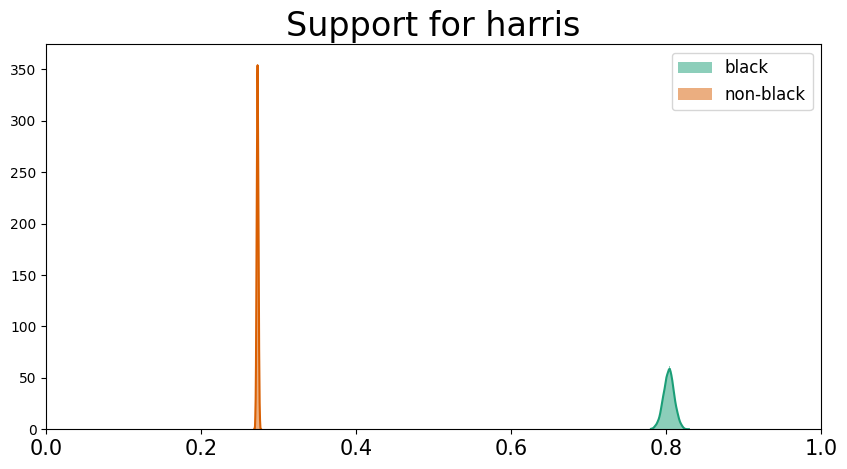

In [3]:
models['harris']['black'].plot_kde()

In [4]:
print(models['harris']['other'].summary())

Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        other for harris is
        0.361
        The posterior mean for the district-level voting preference of
        non-other for harris is
        0.333
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        other for harris is
        [0.27074197 0.42667934]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-other for harris is
        [0.32972044 0.33698275]
        


### Format Fitted Model Data

In [5]:
posterior_means = models['harris']['white'].posterior_mean_voting_prefs
print("white support for harris", posterior_means[0]) # group
print("non-white support for harris ", posterior_means[1]) # complement

white support for harris 0.22051830262629735
non-white support for harris  0.765533167167667


In [6]:
credible_interval_95 = models['harris']['white'].credible_interval_95_mean_voting_prefs
print("white support for harris", credible_interval_95[0]) # group
print("non-white support for harris ", credible_interval_95[1]) # complement

white support for harris [0.21741975 0.22367832]
non-white support for harris  [0.7543676  0.77670548]


In [7]:
sampled_voting_prefs = models['harris']['white'].sampled_voting_prefs # ei.sampled_voting_prefs is samples of district-level voter preference: list of length 2
#sampled_voting_prefs[0] samples of district-wide support of specified group for specified candidate
#sampled_voting_prefs[1] samples of district-wide support of (complement of specified group) for specified candidate

print("white support for harris", sampled_voting_prefs[0]) # group
print("non-white support for harris ", sampled_voting_prefs[1]) # complement

white support for harris [0.21967395 0.22023791 0.22033872 ... 0.22256566 0.22096044 0.2206701 ]
non-white support for harris  [0.7673223  0.76263247 0.76257251 ... 0.75557249 0.76357688 0.7673633 ]


In [21]:
group_samples = sampled_voting_prefs[0]
complement_samples = sampled_voting_prefs[1]

xs = np.linspace(0, 1, 100)
group_density = gaussian_kde(group_samples)(xs)
complement_density = gaussian_kde(complement_samples)(xs)

density_dict = {
    "group": [{"x": float(x), "y": float(y)} for x, y in zip(xs, group_density)],
    "complement": [{"x": float(x), "y": float(y)} for x, y in zip(xs, complement_density)]
}

### Testing Densities

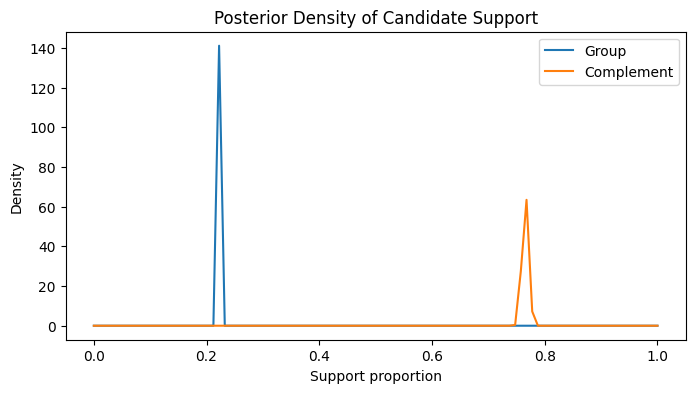

In [22]:
group_xs = [pt['x'] for pt in density_dict['group']]
group_ys = [pt['y'] for pt in density_dict['group']]
comp_xs  = [pt['x'] for pt in density_dict['complement']]
comp_ys  = [pt['y'] for pt in density_dict['complement']]

plt.figure(figsize=(8, 4))
plt.plot(group_xs, group_ys, label="Group")
plt.plot(comp_xs, comp_ys, label="Complement")
plt.xlabel("Support proportion")
plt.ylabel("Density")
plt.title("Posterior Density of Candidate Support")
plt.legend()
plt.show()

In [56]:
def compute_overlap(xs, f1, f2):
    min_density = np.minimum(f1, f2)
    overlap = np.trapezoid(min_density, xs)
    total_f1 = np.trapezoid(f1, xs) 
    return overlap / total_f1

In [60]:
xs = np.linspace(0, 1, 1000)

def group_overlaps_with_white(candidate, group_b, xs):
    white_samples = models[candidate]['white'].sampled_voting_prefs[0]
    group_samples = models[candidate][group_b].sampled_voting_prefs[0]

    f_white = gaussian_kde(white_samples)(xs)
    f_group = gaussian_kde(group_samples)(xs)

    return compute_overlap(xs, f_white, f_group)

for candidate in ['harris', 'trump']:
    print(f"\n{candidate.upper()}")
    for group in ['latino', 'black', 'other']:
        overlap = group_overlaps_with_white(candidate, group, xs)
        print(f"  White vs {group}: {overlap*100:.4f}%")


HARRIS
  White vs latino: 0.0000%
  White vs black: 0.0000%
  White vs other: 0.0037%

TRUMP
  White vs latino: 0.0000%
  White vs black: 0.0000%
  White vs other: 0.0000%


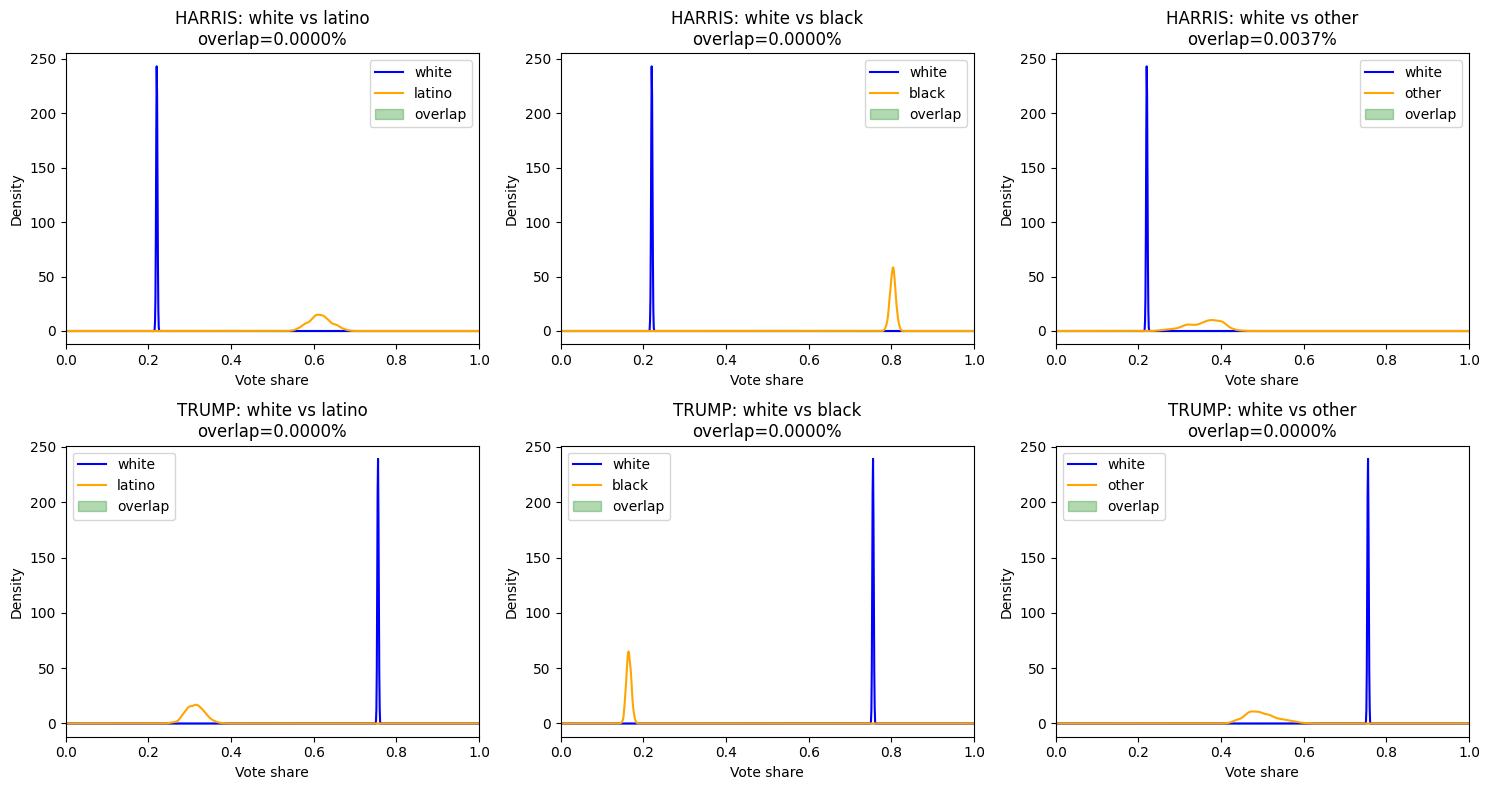

In [63]:
xs = np.linspace(0, 1, 1000)
groups = ['latino', 'black', 'other']
candidates = ['harris', 'trump']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, candidate in enumerate(candidates):
    white_samples = models[candidate]['white'].sampled_voting_prefs[0]
    
    for col, group in enumerate(groups):
        ax = axes[row, col]
        group_samples = models[candidate][group].sampled_voting_prefs[0]

        f_white = gaussian_kde(white_samples)(xs)
        f_group = gaussian_kde(group_samples)(xs)

        ax.plot(xs, f_white, label='white', color='blue')
        ax.plot(xs, f_group, label=group, color='orange')
        ax.fill_between(xs, np.minimum(f_white, f_group), alpha=0.3, color='green', label='overlap')

        overlap = compute_overlap(xs, f_white, f_group)
        ax.set_title(f"{candidate.upper()}: white vs {group}\noverlap={overlap*100:.4f}%")
        ax.set_xlabel("Vote share")
        ax.set_ylabel("Density")
        ax.legend()
        ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

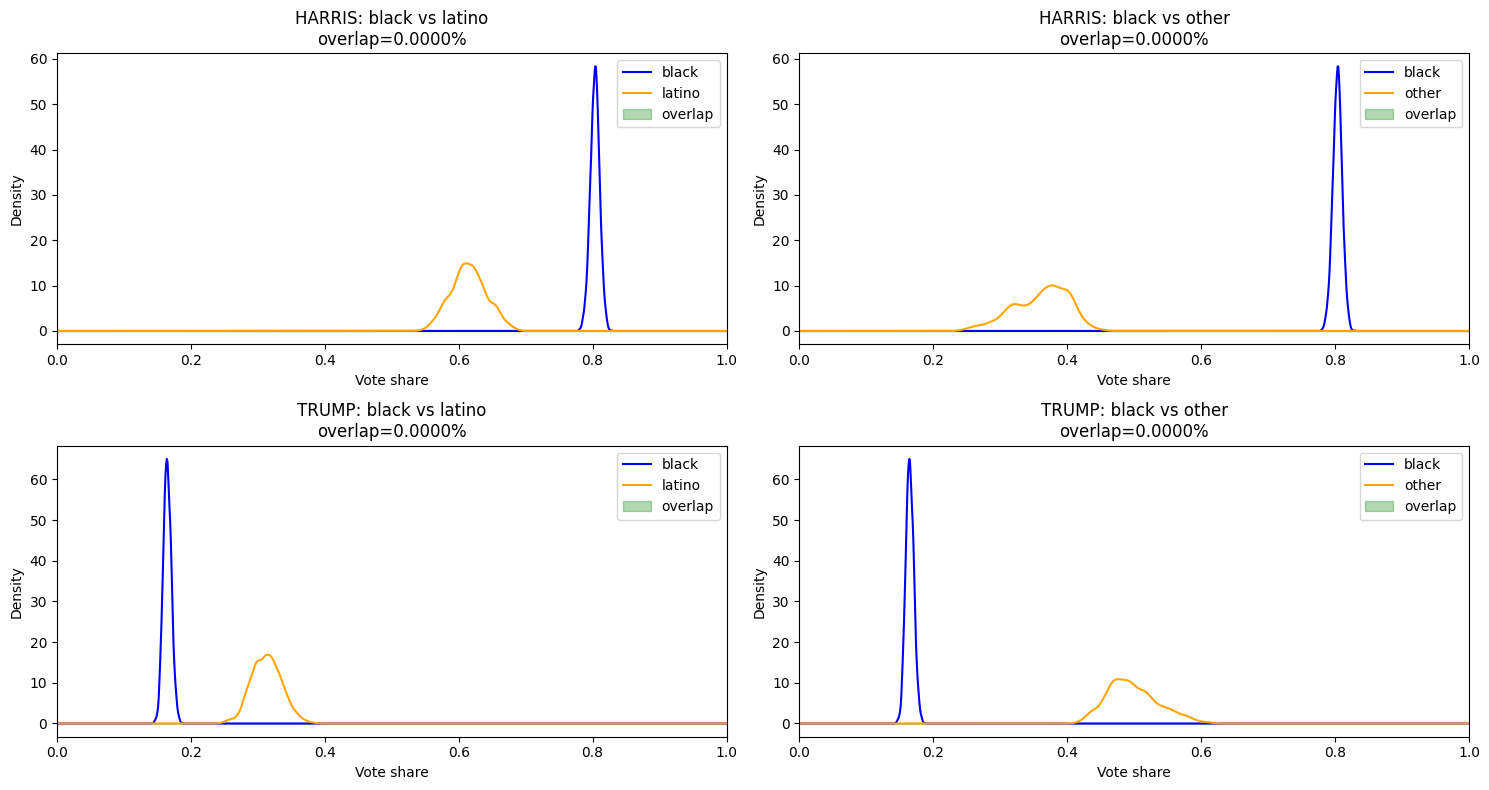

In [ ]:
xs = np.linspace(0, 1, 1000)
groups = ['latino', 'other']
candidates = ['harris', 'trump']

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

for row, candidate in enumerate(candidates):
    black_samples = models[candidate]['black'].sampled_voting_prefs[0]
    
    for col, group in enumerate(groups):
        ax = axes[row, col]
        group_samples = models[candidate][group].sampled_voting_prefs[0]

        f_black = gaussian_kde(black_samples)(xs)
        f_group = gaussian_kde(group_samples)(xs)

        ax.plot(xs, f_black, label='black', color='blue')
        ax.plot(xs, f_group, label=group, color='orange')
        ax.fill_between(xs, np.minimum(f_black, f_group), alpha=0.3, color='green', label='overlap')

        overlap = compute_overlap(xs, f_black, f_group)
        ax.set_title(f"{candidate.upper()}: black vs {group}\noverlap={overlap*100:.4f}%")
        ax.set_xlabel("Vote share")
        ax.set_ylabel("Density")
        ax.legend()
        ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

### Function to Generate Data

In [ ]:
xs = np.linspace(0, 1, 200)
def create_json(models, demographics, candidates):
    ei_json = {"state" : "Arkansas", "candidates": []}

    for candidate in candidates:
        cand_entry = {
            "id": candidate.lower(),
            "groups": {}
        }

        white_samples = models[candidate]['white'].sampled_voting_prefs[0]
        f_white = gaussian_kde(white_samples)(xs)

        for demographic in demographics:
            model = models[candidate][demographic]

            # posterior means
            group_mean, complement_mean = model.posterior_mean_voting_prefs
            # posterior_mean = {
            #     "group": group_mean,
            #     "complement": complement_mean
            # }
            posterior_mean = group_mean

            # credible intervals
            group_ci_95, complement_ci_95 = model.credible_interval_95_mean_voting_prefs
            # credible_interval_95 = {
            #     "group": group_ci_95.tolist(),
            #     "complement": complement_ci_95.tolist()
            # }
            credible_interval_95 = group_ci_95.tolist()

            # densities
            sampled_voting_prefs = model.sampled_voting_prefs            
            group_samples = sampled_voting_prefs[0]
            # complement_samples = sampled_voting_prefs[1]

            group_density = gaussian_kde(group_samples)(xs)
            # complement_density = gaussian_kde(complement_samples)(xs)

            overlap = compute_overlap(xs, f_white, group_density)

            # density = {
            #     "group": [{"x": float(x), "y": float(y)} for x, y in zip(xs, group_density)],
            #     "complement": [{"x": float(x), "y": float(y)} for x, y in zip(xs, complement_density)]
            # }

            density = [{"x": float(x), "y": float(y)} for x, y in zip(xs, group_density)]

            cand_entry["groups"][demographic] = {
                "posterior_mean": posterior_mean,
                "credible_interval_95": credible_interval_95,
                "density": density,
                "overlap": overlap,
            }

        ei_json["candidates"].append(cand_entry)
    
    output_path = "../output/Arkansas/ar_ei_models.json"

    with open(output_path, "w") as f:
        json.dump(ei_json, f, indent=2)            

In [88]:
create_json(models, demographics, candidates)